# <center> Total time and time step verifier (optimization) </center>

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from particletracker.fileparser import field_function_from_file
from particletracker.trajectory import solve_trajectory
from particletracker.trajanalysis import show_deviation_degree, show_deviation_in_Z, plot_2d_trajectory, plot_3d_trajectory

In this notebook you can verify if your time parameters (total timeand time step) are the better. Using a very small time step and a very high total time can unecessarily slow down the code.

## 1. Total time

To discover the total time, you shold use the slower case of the particle's trajectory. That means you should use the smaller current parameters.

**Note:** A common error occours when the total time is smaller than it needed to be. For that reason, tis part of the code id more manual, as you need to choose the time mannualy.

In [2]:
''' ==== Particle features ==== '''
m = 939.3      # proton mass (MeV/c²)
q = 1          # proton charge (elementary charge)



''' === Initial conditions === '''
x0, y0, z0 = -0.07573, 0, -0.35   # initial coordinates (m)
v_direction = [((6**0.5)-(2**0.5))/4, 0, ((6**0.5)+(2**0.5))/4]    # velocity vector
Ec0 = 0.1008                   # initial particle's kinetic energy 


''' === Trajectory solution === '''
method = 'boris'            # choose between "boris" and "rk4"
total_t_list = [3e-6, 8e-6, 1e-6]             # total elapsed time (s)

traj_distance = 0.685761        # total distance of particle's trajectory in X axis (m)



''' === Fields === '''
e_field = lambda ponto: [0, 0, 0]       # force electric field to be 0 at all points

file = '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=2.5A_ID=5481.dat'

desired_x = -0.071212
desired_z = 0.335761


colors = ['red', 'blue', 'green']

total time = 3e-06
Z1 = 0.34419756786286465
The final x value is approximately -0.07125407488250315
total time = 8e-06
Z1 = 0.36967399748354396
The final x value is approximately -0.07077305706889762
total time = 1e-06
Z1 = 0.3399566155761575
The final x value is approximately -0.07125409987228574


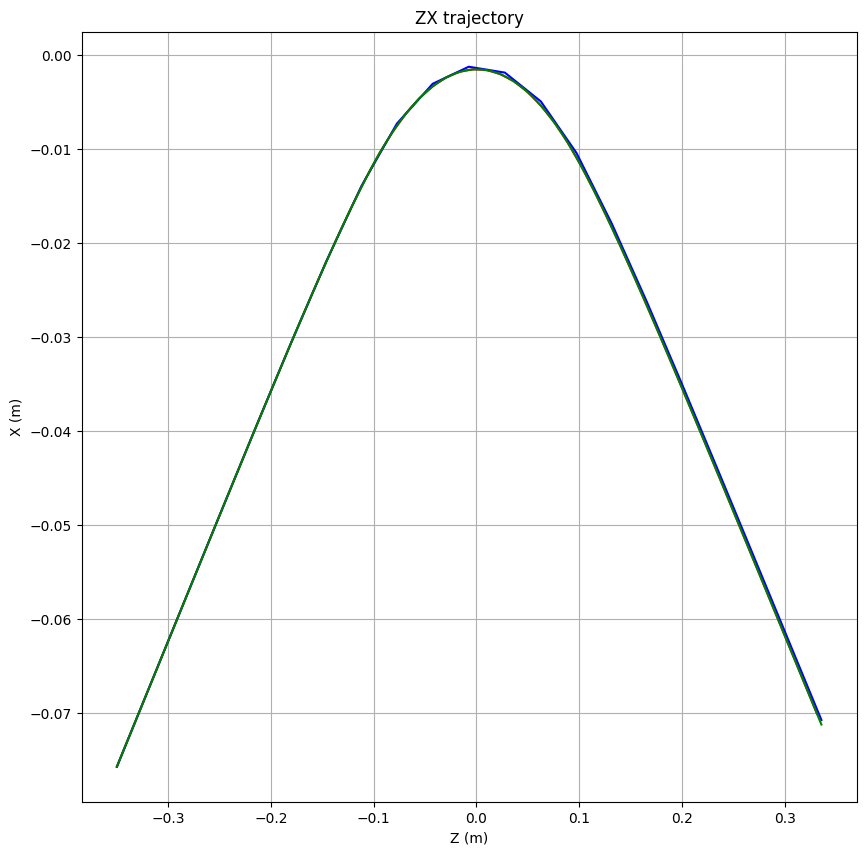

In [3]:
b_field = field_function_from_file(file, '\t', 17)
fig = plt.figure(figsize=(10, 10))
plt.xlabel('Z (m)')
plt.ylabel('X (m)')
plt.grid(True)
plt.axis()
plt.title('ZX trajectory')

for total_t, color in zip(total_t_list, colors):
    print(f'total time = {total_t}')

    step = total_t/1000 
    
    df = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

    final_x = show_deviation_in_Z(df, desired_z)

    condition = df['z(m)'] > (traj_distance-abs(df['z(m)'].iloc[0]))
    result = df.drop(df[condition].index)

    plt.plot(result['z(m)'], result['x(m)'], color, linewidth=1.5)

    print('=====================')

## 2. Time step

To discover the time step, you can use any case of the particle's trajectory, but it's recommended to use the fastest one. That means you should use the biggest current parameters.

In [4]:
''' ==== Particle features ==== '''
m = 939.3      # proton mass (MeV/c²)
q = 1          # proton charge (elementary charge)



''' === Initial conditions === '''
x0, y0, z0 = -0.07573, 0, -0.35   # initial coordinates (m)
v_direction = [((6**0.5)-(2**0.5))/4, 0, ((6**0.5)+(2**0.5))/4]    # velocity vector
Ec0 = 2.5341                   # initial particle's kinetic energy 


''' === Trajectory solution === '''
method = 'boris'            # choose between "boris" and "rk4"
total_t = 3e-6           # total elapsed time (s)
step_list = [total_t/10, total_t/100, total_t/1000, total_t/10000, total_t/100000]

traj_distance = 0.685761        # total distance of particle's trajectory in X axis (m)



''' === Fields === '''
e_field = lambda ponto: [0, 0, 0]       # force electric field to be 0 at all points

file = '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=12.5A_ID=5479.dat'

desired_x = -0.071212
desired_z = 0.335761


colors = ['red', 'blue', 'green', 'orange', 'purple']

step = 3e-07
Z1 = 6.037404021233762
The final x value is approximately 0.09969866175612122
step = 3.0000000000000004e-08
Z1 = 0.9250158696506546
The final x value is approximately 0.10689311252941941
step = 3e-09
Z1 = 0.3566817730638674
The final x value is approximately -0.07581122872736393
step = 3e-10
Z1 = 0.33840924530280886
The final x value is approximately -0.07121497260380498
step = 3e-11
Z1 = 0.3358612741167555
The final x value is approximately -0.07121306024568322


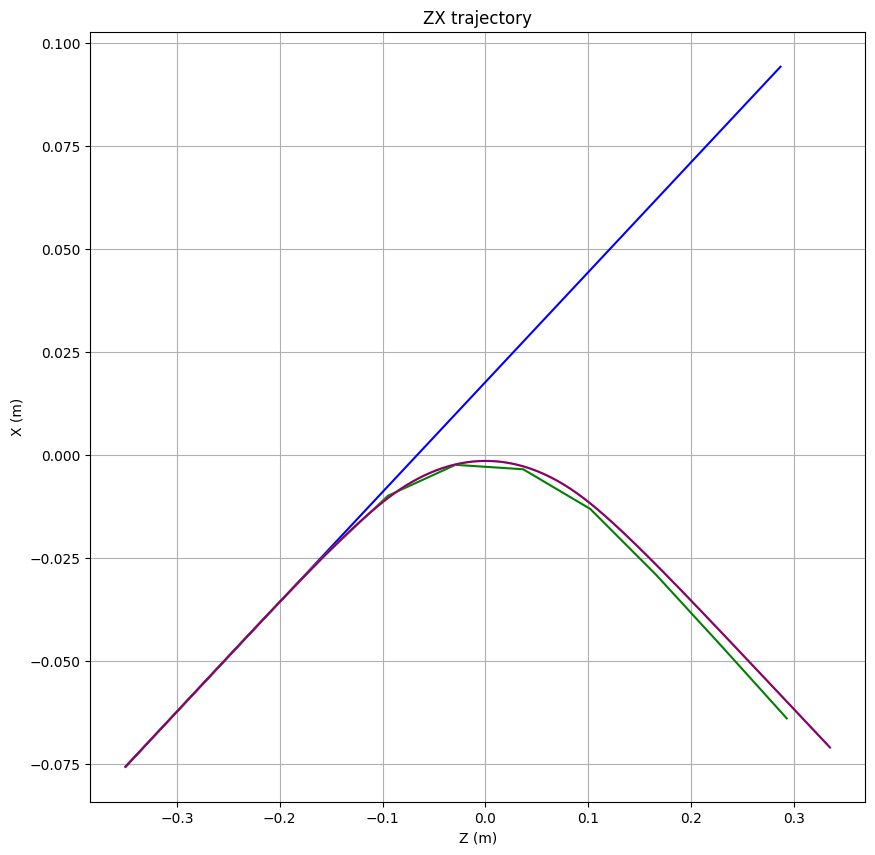

In [5]:
b_field = field_function_from_file(file, '\t', 17)
fig = plt.figure(figsize=(10, 10))
plt.xlabel('Z (m)')
plt.ylabel('X (m)')
plt.grid(True)
plt.axis()
plt.title('ZX trajectory')

for step, color in zip(step_list, colors):
    print(f'step = {step}')
    
    df = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

    final_x = show_deviation_in_Z(df, desired_z)

    condition = df['z(m)'] > (traj_distance-abs(df['z(m)'].iloc[0]))
    result = df.drop(df[condition].index)

    plt.plot(result['z(m)'], result['x(m)'], color, linewidth=1.5)

    print('=====================')